In [1]:
# Run this cell to set up packages for lecture.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display, IFrame

path = 'lectures/lec05'
if not Path("data").exists() or not Path("images").exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    !unzip -q -o /content/course.zip "cosmos-ml-cluster-2026-main/{path}/data/*" "cosmos-ml-cluster-2026-main/{path}/images/*" -d /content/course-assets
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/data .
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/images .

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.5,
    'grid.color': '#999999',
    'grid.alpha': 0.6,
    'font.weight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.fontsize': 11,
    'legend.title_fontsize': 12,
})

np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option("display.max_rows", 7)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

def binning_animation():
    src = "https://docs.google.com/presentation/d/17-vkRiBApVy9oZUu87NCVtuZvyq6YpqxyGF5vvXxEA8/embed?start=false&loop=false&delayms=60000&rm=minimal"
    width = 900
    height = 270
    display(IFrame(src, width, height))

def show_def():
    src = "https://docs.google.com/presentation/d/1iDoZctoUIAn7M5GeUT1D4q76Uwlub11TkYJWllS9vrM/embed?start=false&loop=false&delayms=60000&rm=minimal"
    width = 960
    height = 569
    display(IFrame(src, width, height))


# Lecture 5 - Histograms, Functions, and Applying

## COSMOS ML Cluster 2026

### Agenda

- Distributions.
- Density histograms.
- Functions.
- Applying functions to DataFrames.

### The data: exoplanets discovered by NASA 🪐

An [exoplanet](https://exoplanets.nasa.gov/what-is-an-exoplanet/overview/) is a planet outside our solar system. NASA has discovered over 5,000 exoplanets so far in its [search for signs of life beyond Earth](https://exoplanets.nasa.gov/search-for-life/big-questions/). 👽 

|Column |Contents|
|----------|------------|
`'Distance'`| Distance from Earth, in light years.
`'Magnitude'`|	[Apparent magnitude](https://en.wikipedia.org/wiki/Apparent_magnitude#), which measures brightness in such a way that brighter objects have **lower** values.
`'Type'`|  Categorization of planet based on its composition and size.
`'Year'`|	When the planet was discovered.
`'Detection'`|	The method of detection used to discover the planet.
`'Mass'`|	The ratio of the planet's mass to Earth's mass. 
`'Radius'`|  The ratio of the planet's radius to Earth's radius.

In [2]:
exo = pd.read_csv('data/exoplanets.csv').set_index('Name')

types = (exo
    .get(['Type', 'Mass', 'Radius', 'Magnitude', 'Distance'])
    .groupby('Type')
    .mean()
)

exo

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
11 Comae Berenices b,304.0,4.72,Gas Giant,2007,Radial Velocity,6165.90,11.88
11 Ursae Minoris b,409.0,5.01,Gas Giant,2009,Radial Velocity,4684.81,11.99
14 Andromedae b,246.0,5.23,Gas Giant,2008,Radial Velocity,1525.58,12.65
...,...,...,...,...,...,...,...
YZ Ceti b,12.0,12.07,Terrestrial,2017,Radial Velocity,0.70,0.91
YZ Ceti c,12.0,12.07,Super Earth,2017,Radial Velocity,1.14,1.05
YZ Ceti d,12.0,12.07,Super Earth,2017,Radial Velocity,1.09,1.03


## Distributions

### What is the distribution of a variable?

- The distribution of a variable consists of all values of the variable that occur in the data, along with their frequencies.
- Distributions help you understand:
    > _How often does a variable take on a certain value?_
- Both categorical and numerical variables have distributions.

### Distributions of categorical variables

The distribution of a categorical variable can be displayed as a table or bar chart, among other ways!

For example, let's look at the distribution of exoplanet `'Type'`s. To do so, we'll need to group.

In [3]:
# Remember, when we group and use .count(), the column names aren't meaningful.
type_counts = exo.groupby('Type').count()
type_counts

,Distance,Magnitude,Year,Detection,Mass,Radius
Type,,,,,,
Gas Giant,1480,1480,1480,1480,1480,1480
Neptune-like,1793,1793,1793,1793,1793,1793
Super Earth,1577,1577,1577,1577,1577,1577
Terrestrial,193,193,193,193,193,193


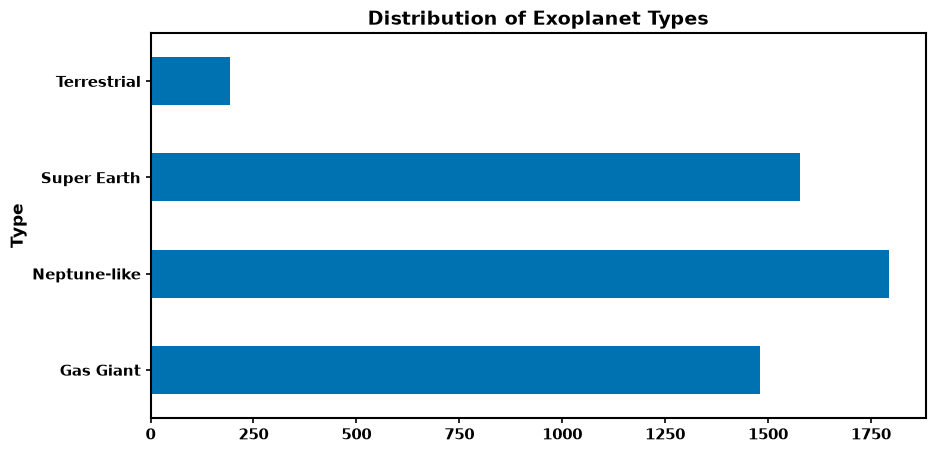

In [4]:
# As a result, we could have set y='Magnitude', for example, and gotten the same plot.
type_counts.plot(kind='barh', y='Distance', 
                 legend=False, title='Distribution of Exoplanet Types');

Notice the optional `title` argument. Some other useful optional arguments are `legend`, `figsize`, `xlabel`, and `ylabel`. There are [many optional arguments](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

It looks like terrestrial exoplanets are the most rare in the dataset. They also have the smallest average radius of any `'Type'`.

In [5]:
types

,Mass,Radius,Magnitude,Distance
Type,,,,
Gas Giant,1472.39,12.74,10.30,1096.40
Neptune-like,15.28,3.11,13.52,2189.02
Super Earth,5.81,1.58,13.85,1916.26
Terrestrial,1.62,0.85,13.45,1373.60


Let's look into them further!

### Terrestrial exoplanets 🌑

In [6]:
terr = exo[exo.get('Type') == 'Terrestrial']
terr

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
EPIC 201497682 b,825.0,13.95,Terrestrial,2019,Transit,0.26,0.69
EPIC 201757695.02,1884.0,14.97,Terrestrial,2020,Transit,0.69,0.91
EPIC 201833600 c,840.0,14.71,Terrestrial,2019,Transit,0.97,1.00
...,...,...,...,...,...,...,...
TRAPPIST-1 e,41.0,17.02,Terrestrial,2017,Transit,0.69,0.92
TRAPPIST-1 h,41.0,17.02,Terrestrial,2017,Transit,0.33,0.76
YZ Ceti b,12.0,12.07,Terrestrial,2017,Radial Velocity,0.70,0.91


Let's focus on the `'Radius'` column of `terr`. To learn more about it, we can use the `.describe()` method.

In [7]:
terr.get('Radius').describe()

count    193.00
mean       0.85
std        0.26
          ...  
50%        0.86
75%        0.92
max        3.13
Name: Radius, Length: 8, dtype: float64

But how do we visualize its distribution?

### Visualizing the distribution of `'Radius'`, a numerical variable

- A few slides ago, we looked at the distribution of `'Type'`, which is a categorical variable.
- Now, we'll look at the distribution of `'Radius'`, which is a numerical variable. 
- As we'll see, **a bar chart is not the right choice of visualization for the distribution of a numerical variable**.

To try and see the distribution of `'Radius'`, we need to group by that column and count how many terrestrial planets there are of each radius.

In [8]:
terr_radius = terr.groupby('Radius').count()
terr_radius = (terr_radius
                 .assign(Count=terr_radius.get('Distance'))
                 .get(['Count'])
              )
terr_radius

,Count
Radius,
0.37,1
0.40,1
0.47,1
...,...
1.80,1
2.85,1
3.13,1


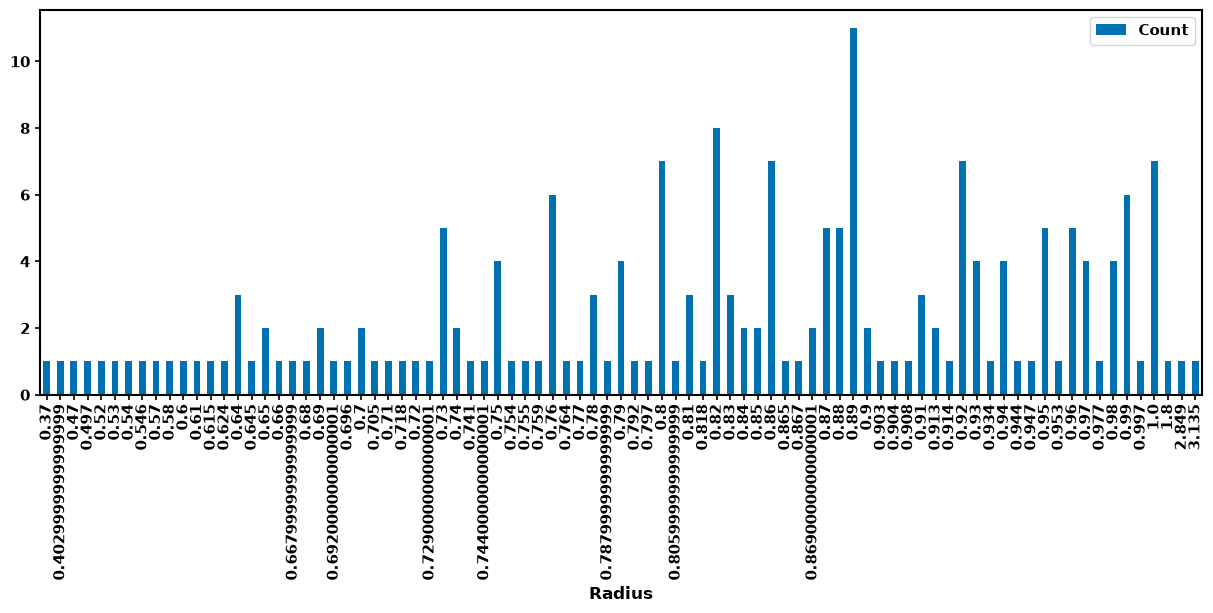

In [9]:
terr_radius.plot(kind='bar', y='Count', figsize=(15, 5));

The horizontal axis should be numerical (like a number line), not categorical. There should be more space between certain bars than others.

For instance, the planet with `'Radius'` 1.8 is 80% larger than the planet with `'Radius'` 1, but they appear to be about the same size here.

## Density histograms

### Density histograms show the distribution of numerical variables

Instead of a bar chart, we'll visualize the distribution of a numerical variable with a **density histogram**. Let's see what a density histogram for `'Radius'` looks like. What do you notice about this visualization?

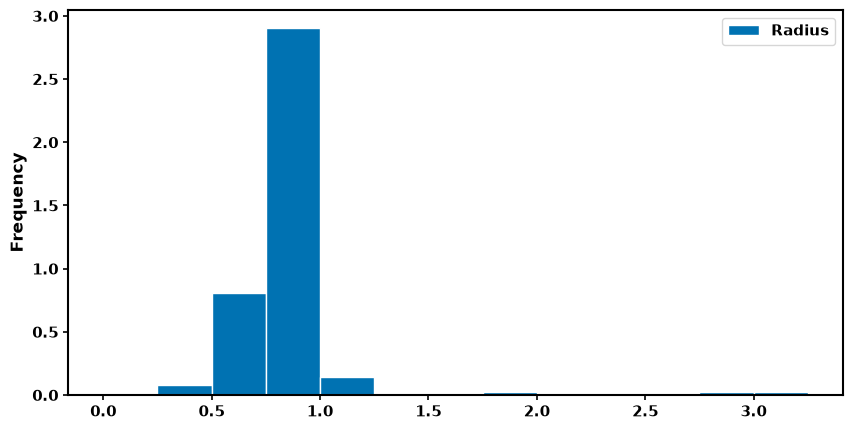

In [10]:
# Ignore the code for right now.
terr.plot(kind='hist', y='Radius', density=True, bins = np.arange(0, 3.5, 0.25), ec='w');

In [11]:
# There are 7 terrestrial exoplanets with a radius of exactly 1.0,
# but the height of the bar starting at 1.0 is not 7!
terr[terr.get('Radius') == 1]

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
EPIC 201833600 c,840.0,14.71,Terrestrial,2019,Transit,0.97,1.0
EPIC 206215704 b,358.0,17.83,Terrestrial,2019,Transit,0.97,1.0
K2-157 b,973.0,12.94,Terrestrial,2018,Transit,0.97,1.0
K2-239 c,101.0,14.63,Terrestrial,2018,Transit,0.97,1.0
Kepler-1417 b,3235.0,14.04,Terrestrial,2016,Transit,0.97,1.0
Kepler-1464 c,3757.0,14.36,Terrestrial,2016,Transit,0.97,1.0
Kepler-392 b,2223.0,13.53,Terrestrial,2014,Transit,0.97,1.0


### First key idea behind histograms: Binning 🗑️

- Binning is the act of counting the number of numerical values that fall within ranges defined by two endpoints. These ranges are called “bins”.
- A value falls in a bin if it is **greater than or equal to the left** endpoint and **less than the right** endpoint.
    - [a, b): a is included, b is not.
- The width of a bin is its right endpoint minus its left endpoint.


In [12]:
binning_animation()

### Plotting a density histogram

- **Density histograms** (not bar charts!) visualize the distribution of a single numerical variable by placing numbers into bins.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='hist', 
    y=column_name,
    density=True
)
```
- Optional but recommended: Use `ec='w'` to see where bins start and end more clearly (edge color = white).

### Customizing the bins

- By default, Python will bin your data into 10 equally sized bins.
- You can specify another number of equally sized bins by setting the optional argument `bins` equal to some other integer value.
- You can also specify custom bin start and endpoints by setting `bins` equal to a list or array of bin endpoints.

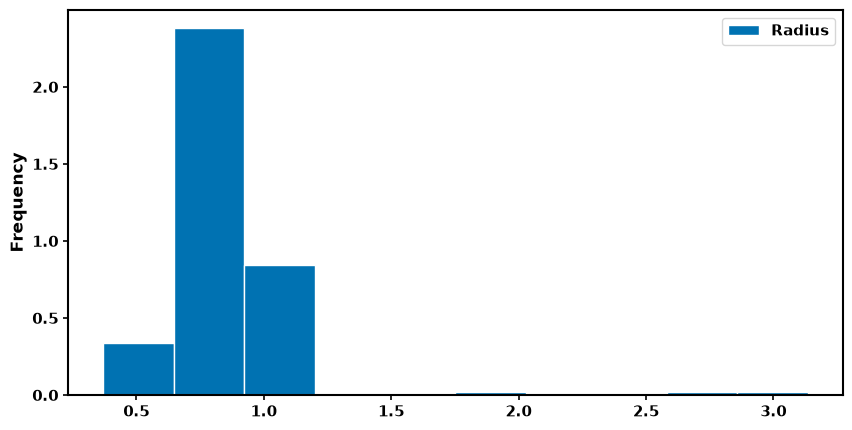

In [13]:
# There are 10 bins by default, some of which are empty.
terr.plot(kind='hist', y='Radius', density=True, ec='w');

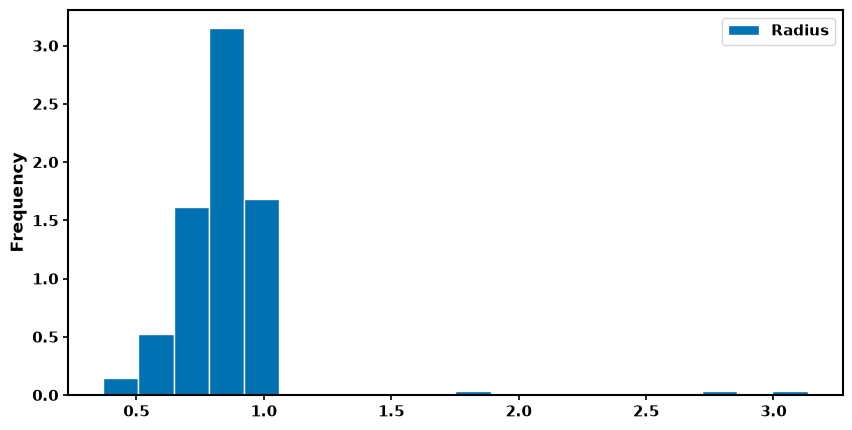

In [14]:
terr.plot(kind='hist', y='Radius', density=True, bins=20, ec='w');

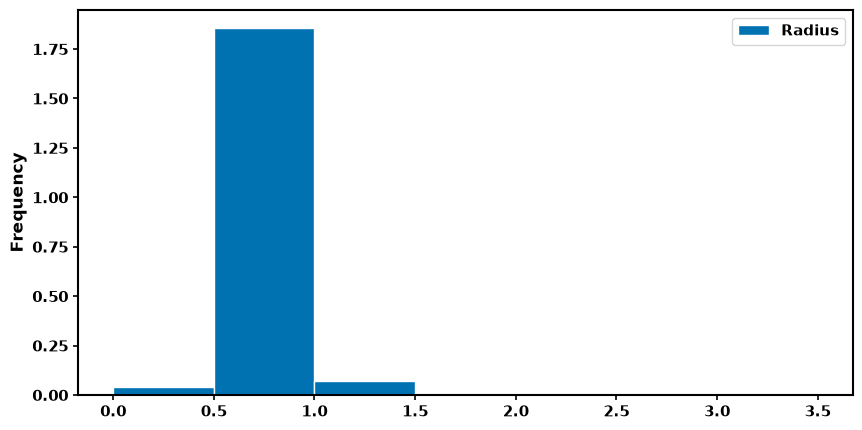

In [15]:
terr.plot(kind='hist', y='Radius', density=True, bins=[0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5], ec='w');

In the three histograms above, what is different and what is the same?

### Observations
- The general shape of all three histograms is the same, regardless of the bins.
- More bins gives a finer, more granular picture of the distribution of the variable `'Radius'`.
- The $y$-axis values seem to change a lot when we change the bins. Hang onto that thought; we'll see why shortly.

### Bin details

- In a histogram, only the last bin is inclusive of the right endpoint!
- The bins you specify don't have to include all data values; data values not in any bin won't be shown in the histogram.
- For equally sized bins, use `np.arange`.
    - Be **very careful** with the endpoints. 
    - For example, `bins=np.arange(4)` creates the bins [0, 1), [1, 2), [2, 3].
- Bins can have different sizes!

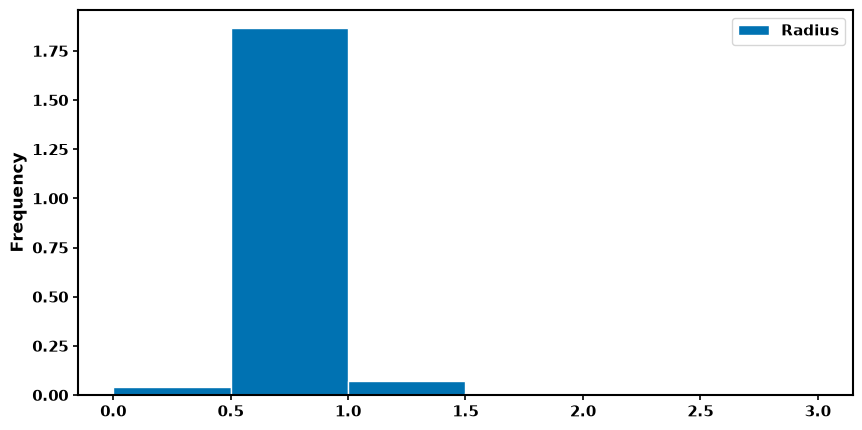

In [16]:
terr.plot(kind='hist', y='Radius', density=True,
            bins=np.arange(0, 3.5, 0.5),
            ec='w');

In [17]:
terr.sort_values('Radius', ascending=False)

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
Kepler-33 c,3944.0,14.10,Terrestrial,2011,Transit,0.39,3.13
K2-138 f,661.0,12.25,Terrestrial,2017,Transit,1.63,2.85
Kepler-11 b,2108.0,13.82,Terrestrial,2010,Transit,1.90,1.80
...,...,...,...,...,...,...,...
Kepler-102 b,352.0,12.07,Terrestrial,2014,Transit,4.30,0.47
Kepler-444 b,119.0,8.87,Terrestrial,2015,Transit,0.04,0.40
Kepler-37 e,209.0,9.77,Terrestrial,2014,Transit Timing Variations,0.03,0.37


In the above example, the terrestrial exoplanet with the largest radius (Kepler-33 c) is not included because the rightmost bin is [2.5, 3.0] and Kepler-33 c has a `'Radius'` of 3.13.

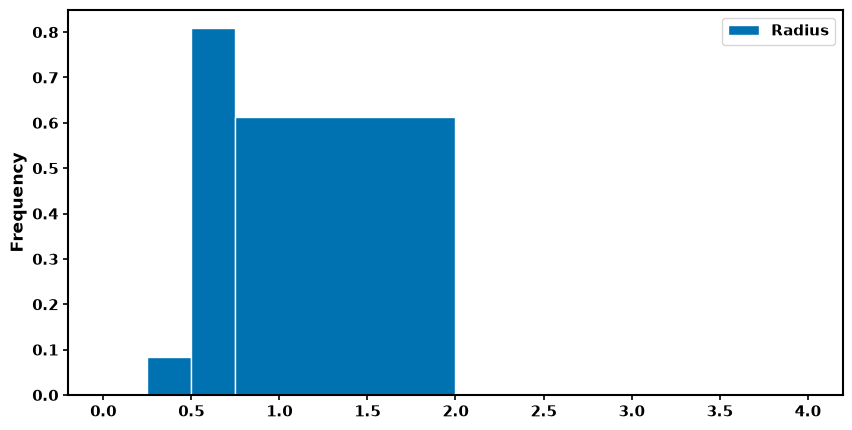

In [18]:
terr.plot(kind='hist', y='Radius', density=True,
          bins=[0, 0.25, 0.5, 0.75, 2, 4], ec='w');

In the above example, the bins have different widths!

### Second key idea behind histograms: Total area is 1

- In a density histogram, the $y$-axis can be hard to interpret, but it's designed to give the histogram a very nice property: 
<br><br>
<center>
    <b>The bars of a density histogram<br>have a combined total area of 1.</b>
</center>

- Important: <b>The area of a bar is equal to the proportion of all data points that fall into that bin</b>.

- Recall from the pretest, proportions and percentages represent the same thing.
    - A proportion is a decimal between 0 and 1, a percentage is between 0\% and 100\%.
    - The proportion 0.34 means 34\%.

### Example calculation

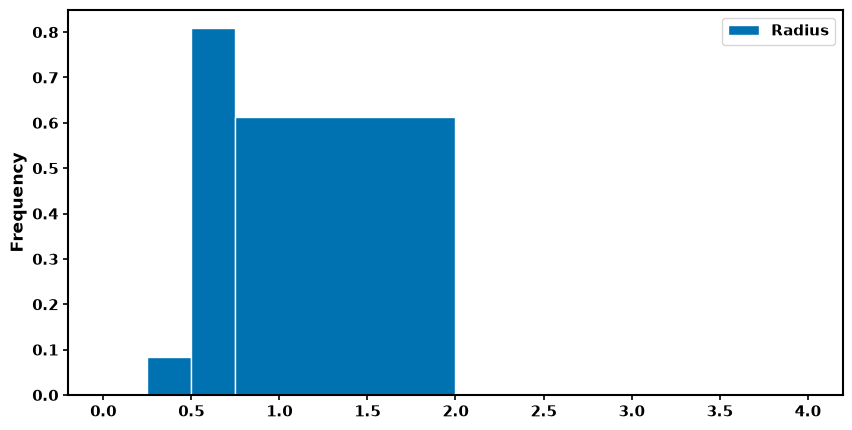

In [19]:
terr.plot(kind='hist', y='Radius', density=True,
          bins=[0, 0.25, 0.5, 0.75, 2, 4], ec='w');

Based on this histogram, what proportion of terrestrial exoplanets have a `'Radius'` between 0.5 and 0.75?

### Example calculation

- The height of the [0.5, 0.75) bar looks to be around 0.8.
- The width of the bin is 0.75 - 0.5 = 0.25.

- Therefore, using the formula for the area of a rectangle,

$$\begin{align}\text{Area} &= \text{Height} \times \text{Width} \\ &= 0.8 \times 0.25 \\ &= 0.2
\end{align}$$

- Since areas represent proportions, this means that the proportion of terrestrial exoplanets with a radius between 0.5 and 0.75 is about 0.2 (or 20\%).

### Check the math 🧮

In [20]:
in_range = terr[(terr.get('Radius') >= 0.5) & (terr.get('Radius') < 0.75)].shape[0]
in_range

39

In [21]:
in_range / terr.shape[0]

0.20207253886010362

This matches the result we got. (Not exactly, since we made an estimate for the height.)

### Calculating heights in a density histogram

Since a bar of a histogram is a rectangle, its area is given by

$$\text{Area} = \text{Height} \times \text{Width}$$

That means

$$\text{Height} = \frac{\text{Area}}{\text{Width}} = \frac{\text{Proportion (or Percentage)}}{\text{Width}}$$

This implies that the units for height are "proportion per ($x$-axis unit)". The $y$-axis represents a sort of *density*, which is why we call it a density histogram.



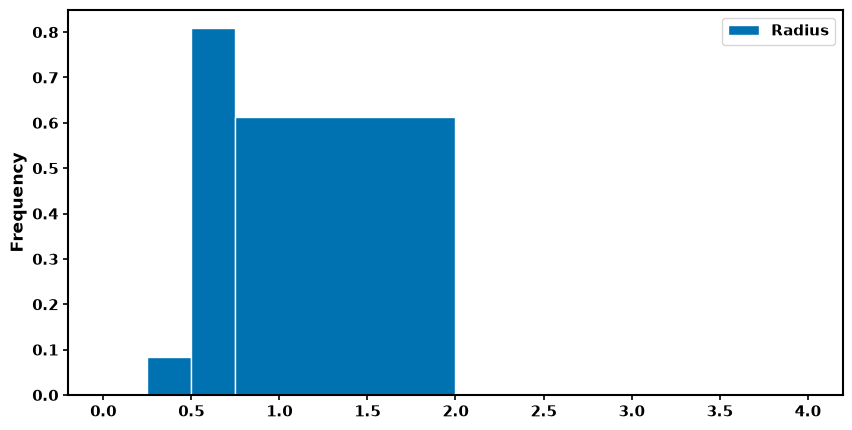

In [22]:
terr.plot(kind='hist', y='Radius', density=True,
          bins=[0, 0.25, 0.5, 0.75, 2, 4], ec='w');

The $y$-axis units here are "proportion per radius", since the $x$-axis represents radius.
  - Unfortunately, the $y$-axis units on the histogram always displays as "Frequency". **This is wrong!**
  - We can fix this with the optional argument `ylabel` but we usually don't.

### Concept Check ✅

Suppose we created a density histogram of people's shoe sizes. 👟 Below are the bins we chose along with their heights.

| Bin | Height of Bar |
| --- | --- |
| [3, 7) | 0.05 |
| [7, 10) | 0.1 |
| [10, 12) | 0.15 |
| [12, 16] | $X$ |


What should the value of $X$ be so that this is a valid histogram?

A. 0.02 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 
B. 0.05 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
C. 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
D. 0.5 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
E. 0.7 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;


<details>
    <summary>✅ Click <b>here</b> to see an explanation after you've answered.</summary>

From the provided bins, we can calculate the bin widths, and then multiply each bin's width by its height to find its area.
The bin $[3, 7)$ has a width of $7-3=4$ and a height of $0.05$, so its area is $4*0.05 = 0.2$. Similarly, the bin $[7, 10)$ has an area of $3*0.1 = 0.3$ and the bin $[10, 12)$ has an area of $2*0.15 = 0.3$. 
    
Adding these up, the total area of the first three bins is $0.2+0.3+0.3=0.8$, and since the total area of all bins in a histogram is always $1$, the fourth bin must have an area of $0.2$. This bin has a width of $4$, so its height must be $0.05$ to make its area $0.2$.
    
</details>

### Review: Types of visualizations

The type of visualization we create depends on the kinds of variables we're visualizing.

- **Scatter plot**: Numerical vs. numerical.
    - Example: Weight vs. height.
- **Line plot**: Sequential numerical (time) vs. numerical.
    - Example: Height vs. time.
- **Bar chart**: Categorical vs. numerical.
    - Example: Heights of different family members.
- **Histogram**: Distribution of numerical.
    
We may interchange the words "plot", "chart", and "graph"; they all mean the same thing.

### Bar charts vs. histograms

Bar chart | Histogram
---|---
Shows the distribution of a categorical variable | Shows the distribution of a numerical variable
Plotted from 2 columns of a DataFrame | Plotted from 1 column of a DataFrame
1 categorical axis,  1 numerical axis | 2 numerical axes
Bars have arbitrary, but equal, widths and spacing | Horizontal axis is numerical and to scale
Lengths of bars are proportional to the numerical quantity of interest | Height measures density; areas are proportional to the proportion (percent) of individuals

### 🌟 Important 🌟

In this class, **"histogram" will always mean a "density histogram".** We will **only** use density histograms. 

*Note:* It's possible to create what's called a *frequency histogram* where the $y$-axis simply represents a count of the number of values in each bin. 

While easier to interpret, frequency histograms don't have the important property that the total area is 1, so they can't be connected to probability in the same way that density histograms can. This property will be useful to us later on in the course.

## Functions

### Defining functions
* We've learned how to do quite a bit in Python:
    * Manipulate arrays, Series, and DataFrames.
    * Perform operations on strings.
    * Create visualizations.
* But so far, we've been restricted to using existing functions (e.g. `max`, `np.sqrt`, `len`) and methods (e.g. `.groupby`, `.assign`, `.plot`). 

### Motivation

- In an earlier activity, you made an array containing all the multiples of 10, in ascending order, that appear on the multiplication table below. 
<center>
    <br>
    <img src=images/mult.jpg width=600>
</center>

In [23]:
multiples_of_10 = np.arange(10, 130, 10)
multiples_of_10

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120])

- **Question**: How would you make an array containing all the multiples of 8, in increasing order, that appear on the multiplication table?

In [24]:
multiples_of_8 = np.arange(8, 13*8, 8)
multiples_of_8

array([ 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96])

### More generally

What if we want to find the multiples of some other number, `k`? We can copy-paste and change some numbers, but that is **prone to error.**

In [25]:
multiples_of_5 = ...
multiples_of_5

Ellipsis

It turns out that we can **define** our own "multiples" **function** just once, and re-use it many times for different values of `k`. 🔁

In [26]:
def multiples(k):
    '''This function returns the 
    first twelve multiples of k.'''
    return np.arange(k, 13*k, k)

In [27]:
multiples(8)

array([ 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96])

In [28]:
multiples(5)

array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])

Note that we only had to specify how to calculate multiples a single time!

### Functions

Functions are a way to divide our code into small subparts to prevent us from writing repetitive code. Each time we **define** our own function in Python, we will use the following pattern.

In [29]:
show_def()

### Functions are "recipes"

- Functions take in inputs, known as **arguments**, do something, and produce some outputs.
- The beauty of functions is that **you don't need to know how they are implemented in order to use them!**
    - For instance, you've been using the function `pd.read_csv` without knowing how it works.
    - This is the premise of the idea of **abstraction** in computer science – you'll hear a lot about this if you take more computer science courses.

In [30]:
multiples(7)

array([ 7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 77, 84])

In [31]:
multiples(-2)

array([ -2,  -4,  -6,  -8, -10, -12, -14, -16, -18, -20, -22, -24])

### Parameters and arguments

`triple` has one **parameter**, `x`.

In [32]:
def triple(x):
    return x * 3

When we call `triple` with the **argument** 5, within the body of `triple`, `x` means 5.

In [33]:
triple(5)

15

We can call `triple` with other arguments, even strings!

In [34]:
triple(7 + 8)

45

In [35]:
triple('cosmos')

'cosmoscosmoscosmos'

### Scope 🩺

The names you choose for a function’s parameters are only known to that function (known as **local scope**). The rest of your notebook is unaffected by parameter names.

In [36]:
def triple(x):
    return x * 3

In [37]:
triple(7)

21

Since we haven't defined an `x` _outside_ of the body of `triple`, our notebook doesn't know what `x` means.

In [38]:
x

NameError: name 'x' is not defined

We can define an `x` outside of the body of `triple`, but that doesn't change how `triple` works.

In [39]:
x = 15

In [40]:
# When triple(12) is called, you can pretend
# there's an invisible line inside the body of x
# that says x = 12.
# The x = 15 above is ignored.
triple(12)

36

### Functions can take 0 or more arguments

Functions can take any number of arguments. 

`greeting` takes no arguments.

In [41]:
def greeting():
    return 'Hi! 👋'

In [42]:
greeting()

'Hi! 👋'

`custom_multiples` takes two arguments!

In [43]:
def custom_multiples(k, how_many):
    '''This function returns the 
    first how_many multiples of k.'''
    return np.arange(k, (how_many + 1)*k, k)

In [44]:
custom_multiples(10, 7)

array([10, 20, 30, 40, 50, 60, 70])

In [45]:
custom_multiples(2, 100)

array([  2,   4,   6, ..., 196, 198, 200], shape=(100,))

### Functions don't run until you call them!

The body of a function is not run until you use (**call**) the function.

Here, we can define `where_is_the_error` without seeing an error message. 

In [46]:
def where_is_the_error(something):
    '''A function to illustrate that errors don't occur 
    until functions are executed (called).'''
    return (1 / 0) + something

It is only when we **call** `where_is_the_error` that Python gives us an error message.

In [47]:
where_is_the_error(5)

ZeroDivisionError: division by zero

### Example: `first_name`

Let's create a function called `first_name` that takes in someone's full name and returns their first name. Example behavior is shown below.
```py
>>> first_name('Ada Lovelace')
'Ada'
```
*Hint*: Use the string method `.split`.

General strategy for writing functions: 
1. First, try and get the behavior to work on a single example. 
2. Then, encapsulate that behavior inside a function.

In [48]:
'Ada Lovelace'.split(' ')[0]

'Ada'

In [49]:
def first_name(full_name):
    '''Returns the first name given a full name.'''
    return full_name.split(' ')[0]

In [50]:
first_name('Ada Lovelace')

'Ada'

In [51]:
# What if there are three names?
first_name('Augusta Ada Lovelace')

'Augusta'

### Returning

- The `return` keyword specifies what the output of your function should be, i.e. what a call to your function will evaluate to.
- Some functions don't have any output and don't use `return`.
    - **If you want to be able to save the output of your function to a variable, you must use `return`!**
- Be careful: `print` and `return` work differently!

In [52]:
def pythagorean(a, b):
    '''Computes the hypotenuse length of a right triangle with legs a and b.'''
    c = (a ** 2 + b ** 2) ** 0.5
    print(c)

In [53]:
x = pythagorean(3, 4)

5.0


In [54]:
# No output – why?
x

In [55]:
# Errors – why?
x + 10

TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'

In [56]:
def better_pythagorean(a, b):
    '''Computes the hypotenuse length of a right triangle with legs a and b, 
       and actually returns the result.
    '''
    c = (a ** 2 + b ** 2) ** 0.5
    return c

In [57]:
x = better_pythagorean(3, 4)
x

5.0

In [58]:
x + 10

15.0

### Returning
Once a function executes a `return` statement, it stops running.

In [59]:
def motivational(quote):
    return 0
    print("Here's a motivational quote:", quote)

In [60]:
motivational('Fall seven times and stand up eight.')

0

## Applying functions to DataFrames

### Sample student data

The DataFrame `roster` contains the names and sections of all students enrolled in a sample class roster. The first names are real, while the last names have been anonymized for privacy.

In [61]:
roster = pd.read_csv('data/roster-anon.csv')
roster

,name,section
0,Camilla Ozqcfu,B
1,Yifan Ignjpe,A
2,Ali Jjsojh,A
...,...,...
491,Qiankang Tzjsbb,D
492,Kim Wxnmuh,C
493,Jazmine Sxcvft,C


### Example: Common first names

What is the most common first name among students in the sample roster? (Any guesses?)

In [62]:
roster

,name,section
0,Camilla Ozqcfu,B
1,Yifan Ignjpe,A
2,Ali Jjsojh,A
...,...,...
491,Qiankang Tzjsbb,D
492,Kim Wxnmuh,C
493,Jazmine Sxcvft,C


- **Problem**: We can't answer that right now, since we don't have a column with first names. If we did, we could group by it.

- **Solution**: Use our function that extracts first names on _every_ element of the `'name'` column.

### Using our `first_name` function

Somehow, we need to call `first_name` on every student's `'name'`.

In [63]:
roster

,name,section
0,Camilla Ozqcfu,B
1,Yifan Ignjpe,A
2,Ali Jjsojh,A
...,...,...
491,Qiankang Tzjsbb,D
492,Kim Wxnmuh,C
493,Jazmine Sxcvft,C


In [64]:
roster.get('name').iloc[0]

'Camilla Ozqcfu'

In [65]:
first_name(roster.get('name').iloc[0])

'Camilla'

In [66]:
first_name(roster.get('name').iloc[1])

'Yifan'

Ideally, there's a better solution than doing this hundreds of times...

### `.apply`

- To **apply** the function `func_name` to every element of column `'col'` in DataFrame `df`, use

<center>
    <code>df.get('col').apply(func_name)</code>
</center>

- The `.apply` method is a **Series** method.
    - **Important**: We use `.apply` on Series, **not** DataFrames.
    - The output of `.apply` is also a Series.

- Pass _just the name_ of the function – don't call it!
    - Good ✅: `.apply(first_name)`.
    - Bad ❌: `.apply(first_name())`.

In [67]:
roster.get('name')

0       Camilla Ozqcfu
1         Yifan Ignjpe
2           Ali Jjsojh
            ...       
491    Qiankang Tzjsbb
492         Kim Wxnmuh
493     Jazmine Sxcvft
Name: name, Length: 494, dtype: str

In [68]:
roster.get('name').apply(first_name)

0       Camilla
1         Yifan
2           Ali
         ...   
491    Qiankang
492         Kim
493     Jazmine
Name: name, Length: 494, dtype: str

### Example: Common first names

In [69]:
roster = roster.assign(
    first=roster.get('name').apply(first_name)
)
roster

,name,section,first
0,Camilla Ozqcfu,B,Camilla
1,Yifan Ignjpe,A,Yifan
2,Ali Jjsojh,A,Ali
...,...,...,...
491,Qiankang Tzjsbb,D,Qiankang
492,Kim Wxnmuh,C,Kim
493,Jazmine Sxcvft,C,Jazmine


Now that we have a column containing first names, we can find the **distribution** of first names.

In [70]:
name_counts = (
    roster
    .groupby('first')
    .count()
    .sort_values('name', ascending=False)
    .get(['name'])
)
name_counts

,name
first,
Andrew,7
Noah,5
Joseph,5
...,...
Heaven,1
Harsh,1
Ziyong,1


### Activity

Below:
- Create a **bar chart** showing the number of students with each first name, but only include first names shared by at least two students.
- Determine the **proportion** of students in the sample roster who have a first name that is shared by at least two students.

*Hint*: Start by defining a DataFrame with only the names in `name_counts` that appeared at least twice. You can use this DataFrame to answer both questions.

<br>

<details>
<summary>✅ Click <b>here</b> to see the solutions <b>after</b> you've tried it yourself.</summary>
    
<pre>

shared_names = name_counts[name_counts.get('name') >= 2]

# Bar chart.
shared_names.sort_values('name').plot(kind='barh', y='name', figsize=(5, 8));

# Proportion = # students with a shared name / total # of students.
shared_names.get('name').sum() / roster.shape[0]

</pre>
    
</details>

In [71]:
...

Ellipsis

In [72]:
...

Ellipsis

### `.apply` works with built-in functions, too!

In [73]:
name_counts.get('name')

first
Andrew    7
Noah      5
Joseph    5
         ..
Heaven    1
Harsh     1
Ziyong    1
Name: name, Length: 427, dtype: int64

In [74]:
# Not necessarily meaningful, but doable.
name_counts.get('name').apply(np.log)

first
Andrew    1.95
Noah      1.61
Joseph    1.61
          ... 
Heaven    0.00
Harsh     0.00
Ziyong    0.00
Name: name, Length: 427, dtype: float64

### Aside: Resetting the index

In `name_counts`, first names are stored in the index, which is **not** a Series. This means we can't use `.apply` on it.

In [75]:
name_counts.index

Index(['Andrew', 'Noah', 'Joseph', 'Ethan', 'Michael', 'Christopher', 'Daniel',
       'Justin', 'Abhinav', 'Jaden',
       ...
       'Ingkawat', 'I-Shan', 'Humza', 'Huilin', 'Honoka', 'Hirkani', 'Hilary',
       'Heaven', 'Harsh', 'Ziyong'],
      dtype='str', name='first', length=427)

In [76]:
name_counts.index.apply(max)

AttributeError: 'Index' object has no attribute 'apply'

To help, we can use `.reset_index()` to turn the index of a DataFrame into a column, and to reset the index back to the default of 0, 1, 2, 3, and so on.

In [77]:
# What is the max of an individual string?
name_counts.reset_index().get('first').apply(max)

0      w
1      o
2      s
      ..
424    v
425    s
426    y
Name: first, Length: 427, dtype: str

### Example: Shared first names and sections

- Suppose you're one of the students who has a first name that is shared with at least one other student.
- Let's try and determine whether someone **in your section** shares the same first name as you.
    - For example, maybe `'Jayden Lcaert'` wants to see if there's another `'Jayden'` in their section. 

Strategy:
1. Which section is `'Jayden Lcaert'` in?
2. How many people in that section have a first name of `'Jayden'`?

In [78]:
roster

,name,section,first
0,Camilla Ozqcfu,B,Camilla
1,Yifan Ignjpe,A,Yifan
2,Ali Jjsojh,A,Ali
...,...,...,...
491,Qiankang Tzjsbb,D,Qiankang
492,Kim Wxnmuh,C,Kim
493,Jazmine Sxcvft,C,Jazmine


In [79]:
which_section = roster[roster.get('name') == 'Jayden Lcaert'].get('section').iloc[0]
which_section

'B'

In [80]:
first_cond = roster.get('first') == 'Jayden' # A Boolean Series!
section_cond = roster.get('section') == which_section # A Boolean Series!
how_many = roster[first_cond & section_cond].shape[0]
how_many

2

### Another function: `shared_first_and_section`

Let's create a function named `shared_first_and_section`. It will take in the **full name** of a student and return **the number** of students in their section with the same first name and section (including them).

*Note*: This is the first function we're writing that involves using a DataFrame within the function – this is fine!

In [81]:
def shared_first_and_section(name):
    # First, find the row corresponding to that full name in roster.
    # We're assuming that full names are unique.
    row = roster[roster.get('name') == name]
    
    # Then, get that student's first name and section.
    first = row.get('first').iloc[0]
    section = row.get('section').iloc[0]
    
    # Now, find all the students with the same first name and section.
    shared_info = roster[(roster.get('first') == first) & (roster.get('section') == section)]
    
    # Return the number of such students.
    return shared_info.shape[0]

In [82]:
shared_first_and_section('Jayden Lcaert')

2

Now, let's add a column to `roster` that contains the values returned by `shared_first_and_section`.

In [83]:
roster = roster.assign(shared=roster.get('name').apply(shared_first_and_section))
roster

,name,section,first,shared
0,Camilla Ozqcfu,B,Camilla,1
1,Yifan Ignjpe,A,Yifan,1
2,Ali Jjsojh,A,Ali,2
...,...,...,...,...
491,Qiankang Tzjsbb,D,Qiankang,1
492,Kim Wxnmuh,C,Kim,1
493,Jazmine Sxcvft,C,Jazmine,1


Let's find all of the students who are in a section with someone that has the same first name as them.

In [84]:
roster[(roster.get('shared') >= 2)].sort_values('shared', ascending=False)

,name,section,first,shared
486,Joseph Jpoelz,C,Joseph,4
411,Joseph Vdhfyo,C,Joseph,4
329,Joseph Jaqwhh,C,Joseph,4
...,...,...,...,...
226,William Mjsrep,D,William,2
154,Jayden Lcaert,B,Jayden,2
2,Ali Jjsojh,A,Ali,2


### Sneak peek

While the DataFrame above contains the information we were looking for, it is not organized very conveniently and it is somewhat redundant. 

Wouldn't it be great if we could create a DataFrame like the one below? We'll see how next time!

<center><img src="images/preview.jpg" width=30%></center>

### Activity

Find the longest first name in the class that is shared by at least two students in the same section.

*Hint*: You'll have to use both `.assign` and `.apply`.

<br>

<details>
<summary>✅ Click <b>here</b> to see the answer <b>after</b> you've tried it yourself.</summary>
    
<pre>

with_len = roster.assign(name_len=roster.get('first').apply(len))
with_len[with_len.get('shared') >= 2].sort_values('name_len', ascending=False).get('first').iloc[0]

</pre>
    
</details>

In [85]:
...

Ellipsis

## Summary, next time

### Summary

- Functions are a way to divide our code into small subparts to prevent us from writing repetitive code.
- The `.apply` method allows us to call a function on every single element of a Series, which usually comes from `.get`ting a column of a DataFrame.

### Next time

More advanced DataFrame manipulations!